## ML for Causal Inference

17 — Predictive Models 101 <br>
18 — Heterogeneous Treatment Effects and Personalization <br>
19 — Evaluating Causal Models <br>
20 — Plug-and-Play Estimators <br>
21 — Meta Learners <br>
22 — Debiased/Orthogonal Machine Learning <br>
23 — Challenges with Effect Heterogeneity and Nonlinearity

In [2]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import statsmodels.formula.api as smf

import os
from sklearn import ensemble
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
style.use("ggplot")

os.getcwd()
os.chdir('/Users/hiro/Documents/github/Causal_Inference')

## 17) Predictive Models 101

Focus on Heterogeneous Treatment Effect $E[Y_1-Y_0|X]$
ML focus on $E[Y|X]$
Frame a problem as a prediction problem to solve with ML

Bingo! We can clearly see that some regions are profitable, like regions 2, 17, 39, and some are not profitable, like regions 0, 9, 29 and the especially bad region 26. This is looking super promising! We can take this and transform into a policy: only do business with the regions that showed to be profitable according to the data that we have here.

We are seeing if $E[NetValue] > 0 $ or $E[Netvalue|Region] > 0$ or $E[NetValue|Region, Age, Income] > 0$


In [19]:
transactions = pd.read_csv("data/customer_transactions.csv")

profitable = (transactions[["customer_id"]]
              .assign(net_value = transactions
                      .drop(columns="customer_id")
                      .sum(axis=1)))

customer_features = (pd.read_csv("data/customer_features.csv")
                     .merge(profitable, on="customer_id"))

print(customer_features.head())

train, test = train_test_split(customer_features, test_size=0.3, random_state=13)
print(train.shape, test.shape)

print(train["net_value"].mean())

   customer_id  region  income  age  net_value
0            0      30    1025   24        130
1            1      41    1649   26         10
2            2      18    2034   33         -6
3            3      20    1859   35        136
4            4       1    1243   26         -8
(7000, 5) (3000, 5)
-29.169428571428572


{1: 2.9729729729729737,
 2: 20.543302704837856,
 4: 10.051075065003388,
 9: 32.08862469914759,
 11: 37.434210420891255,
 12: 37.44213667009524,
 15: 32.09847683044394,
 17: 39.52753893574483,
 18: 41.86162250217046,
 19: 15.62406327716401,
 20: 22.06654814414531,
 21: 24.621030401718578,
 25: 33.97022928360584,
 35: 11.68776141117673,
 37: 27.83183541449011,
 38: 49.740709395699994,
 45: 2.286387928016998,
 49: 17.018537095350286}

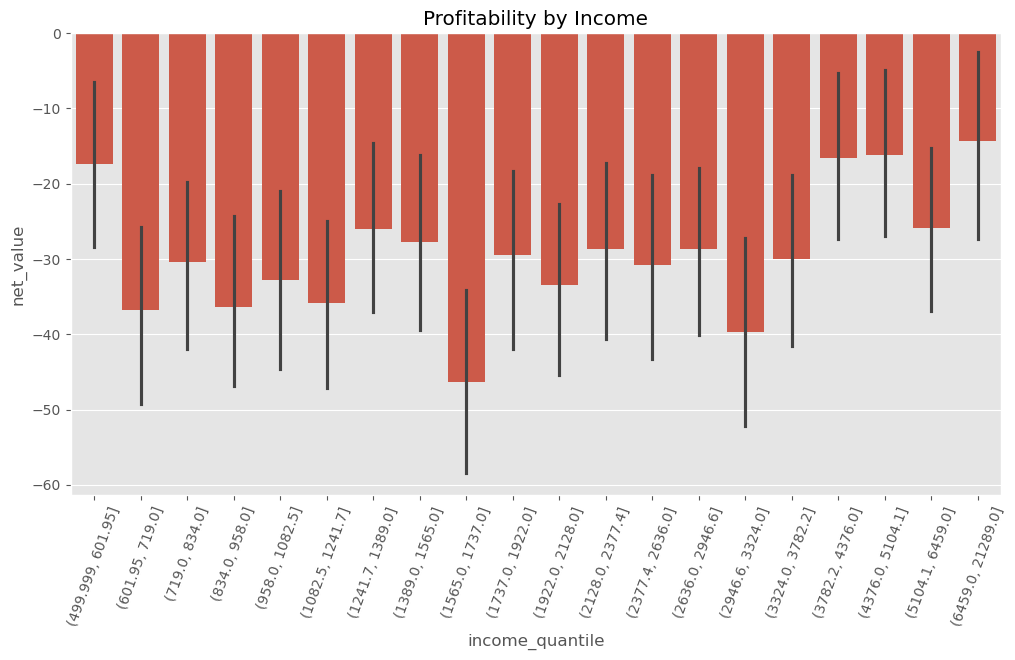

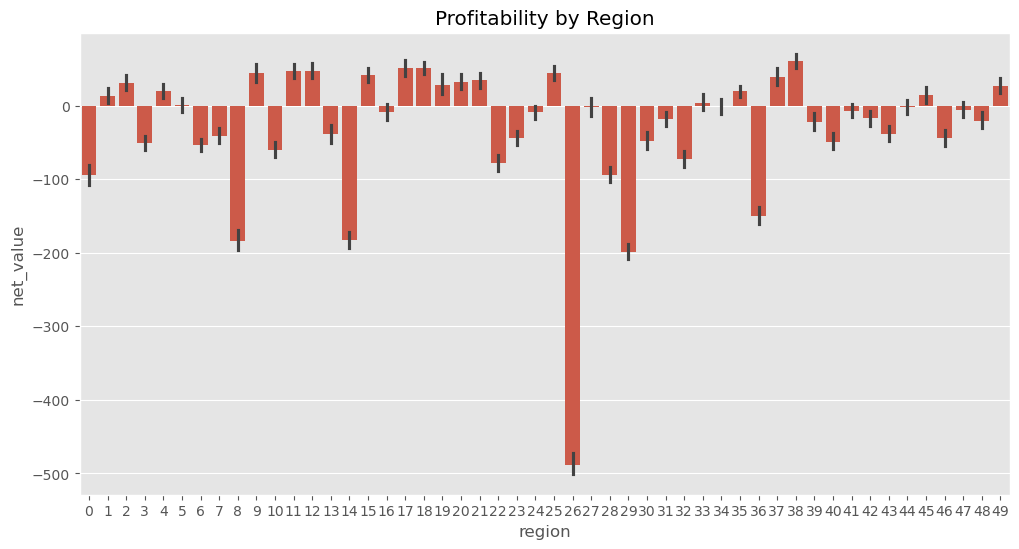

In [20]:
plt.figure(figsize=(12,6))
np.random.seed(123) ## seed because the CIs from seaborn uses boostrap

# pd.qcut create quantiles of a column
sns.barplot(data=train.assign(income_quantile=pd.qcut(train["income"], q=20)), 
            x="income_quantile", y="net_value")
plt.title("Profitability by Income")
plt.xticks(rotation=70);

plt.figure(figsize=(12,6))
np.random.seed(123)
region_plot = sns.barplot(data=train, x="region", y="net_value")
plt.title("Profitability by Region");

regions_to_net = train.groupby('region')['net_value'].agg(['mean', 'count', 'std'])

regions_to_net = regions_to_net.assign(
    lower_bound=regions_to_net['mean'] - 1.96*regions_to_net['std']/(regions_to_net['count']**0.5)
)

regions_to_net_lower_bound = regions_to_net['lower_bound'].to_dict()
regions_to_net = regions_to_net['mean'].to_dict()

# filters regions where the net value lower bound is > 0.
regions_to_invest = {region: net 
                     for region, net in regions_to_net_lower_bound.items()
                     if net > 0}

regions_to_invest

Train R2:  0.7108790300152951
Test R2:  0.6938513063048141


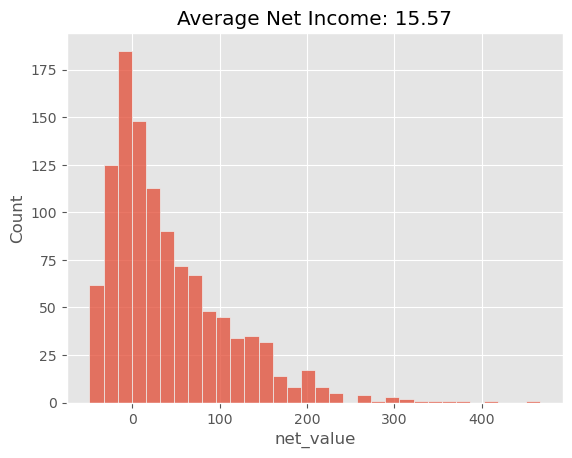

In [22]:
region_policy = (test[test["region"]
                      # filter regions in regions_to_invest
                      .isin(regions_to_invest.keys())]) 

sns.histplot(data=region_policy, x="net_value")
# average has to be over all customers, not just the one we've filtered with the policy
plt.title("Average Net Income: %.2f" % (region_policy["net_value"].sum() / test.shape[0]));

def encode(df): 
    return df.replace({"region": regions_to_net})

model_params = {'n_estimators': 400,
                'max_depth': 4,
                'min_samples_split': 10,
                'learning_rate': 0.01,
                'loss': 'squared_error'}

features = ["region", "income", "age"]
target = "net_value"

np.random.seed(123)

reg = ensemble.GradientBoostingRegressor(**model_params)

# fit model on the training set
encoded_train = train[features].pipe(encode)
reg.fit(encoded_train, train[target]);

train_pred = (encoded_train
              .assign(predictions=reg.predict(encoded_train[features])))

print("Train R2: ", r2_score(y_true=train[target], y_pred=train_pred["predictions"]))
print("Test R2: ", r2_score(y_true=test[target], y_pred=reg.predict(test[features].pipe(encode))))

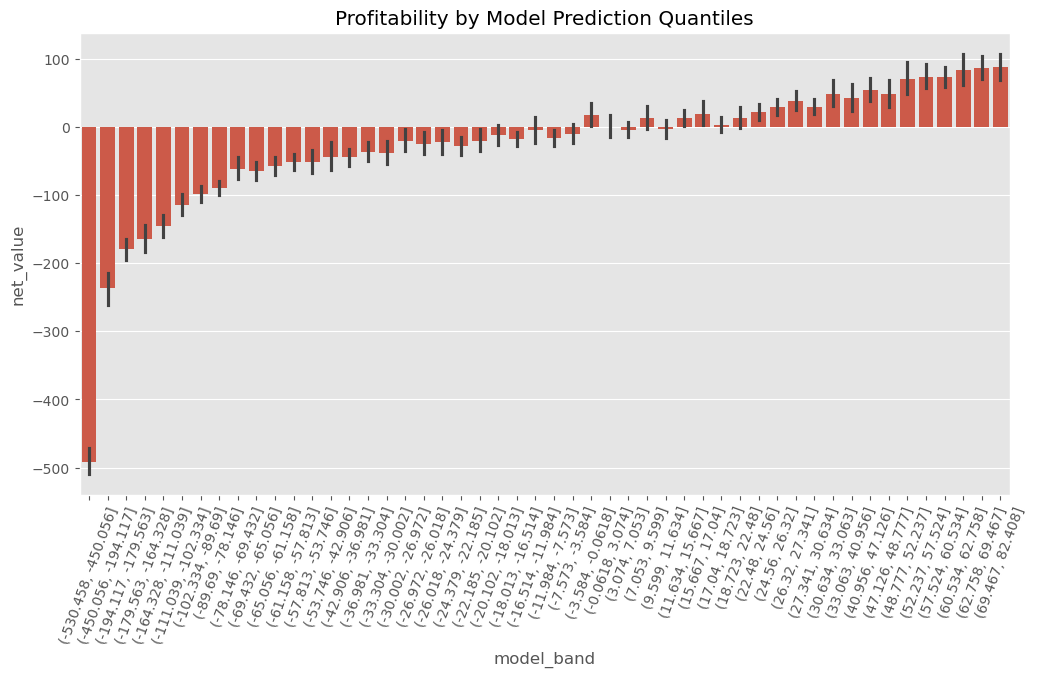

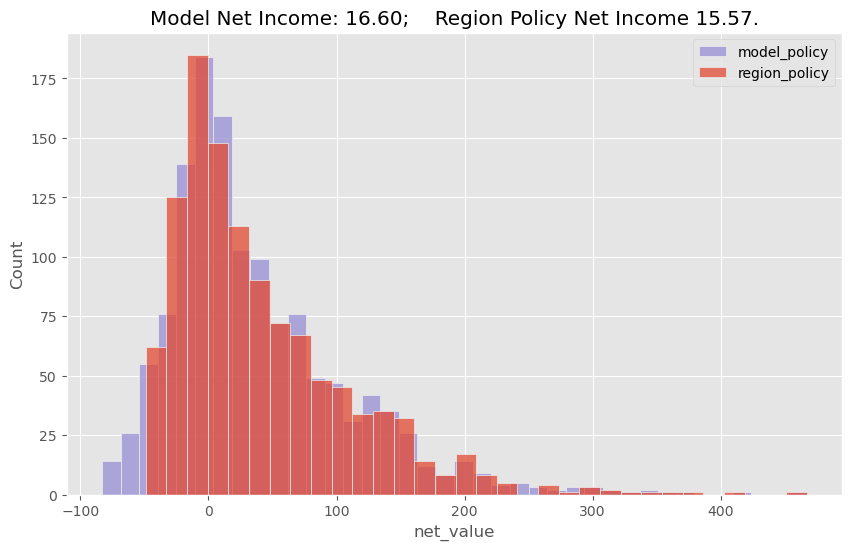

In [25]:
model_policy = test.assign(prediction=reg.predict(test[features].pipe(encode)))

model_policy.head()

plt.figure(figsize=(12,6))

n_bands = 50
bands = [f"band_{b}" for b in range(1,n_bands+1)]

np.random.seed(123)
model_plot = sns.barplot(data=model_policy
                         .assign(model_band = pd.qcut(model_policy["prediction"], q=n_bands)),
                         x="model_band", y="net_value")
plt.title("Profitability by Model Prediction Quantiles")
plt.xticks(rotation=70);

plt.figure(figsize=(10,6))
model_plot_df = (model_policy[model_policy["prediction"]>0])
sns.histplot(data=model_plot_df, x="net_value", color="C2", label="model_policy")

region_plot_df = (model_policy[model_policy["region"].isin(regions_to_invest.keys())])
sns.histplot(data=region_plot_df, x="net_value", label="region_policy")

plt.title("Model Net Income: %.2f;    Region Policy Net Income %.2f." % 
          (model_plot_df["net_value"].sum() / test.shape[0],
           region_plot_df["net_value"].sum() / test.shape[0]))
plt.legend();

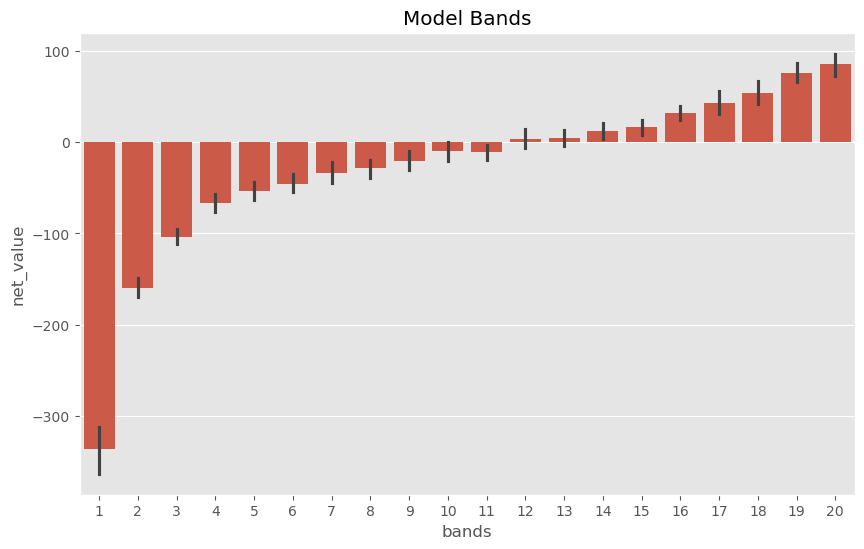

In [27]:
def model_binner(prediction_column, bins):
    # find the bins according to the training set
    bands = pd.qcut(prediction_column, q=bins, retbins=True)[1]
    
    def binner_function(prediction_column):
        return np.digitize(prediction_column, bands)
    
    return binner_function
    

# train the binning function
binner_fn = model_binner(train_pred["predictions"], 20)

# apply the binning
model_band = model_policy.assign(bands = binner_fn(model_policy["prediction"]))
model_band.head()

plt.figure(figsize=(10,6))
sns.barplot(data=model_band, x="bands", y="net_value")
plt.title("Model Bands");

## 18) Heterogeneous Treatment Effects and Personalization


There is both the data generating process and our intervention/treatment
$$E[Y|X,T]$$

So optimiziation $$\arg \max_T E[Y|X,T]$$

Conditional Average Treatment Effect (CATE)

$$E[Y_1 - Y_0|X] \text{ or } E[y'(t)|X]$$

Who do we treat (binary)? What is the right dosage (cont)? Conditional Treatment Effect $\frac{\delta Y}{\delta T}$. For instance, we want price sensitivity/elasticity $\frac{\delta Sales}{\delta Price}$ but can't see it. There is an individual sensitivity $\frac{\delta Y_i}{\delta T_i}$. To estimate, need different days with different prices and see difference in sales

$$ \frac{\delta Y_i}{\delta T_i} \approx \frac{Y(T_i) - Y(T_i + \varepsilon)}{T_i - (T_i + \varepsilon)} $$

but unobservable...

$$y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + e_i$$

$\frac{\delta y_i}{\delta t_i} = \beta_1$. Average Treatment Effect

$$y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i + e_i$$

$\hat{\frac{\delta y_i}{\delta t_i}} = \hat{\beta}_1 + \hat{\beta_3} X_i$ Conditional Average Treatment Effect CATE $E[y'(t)|X]$

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

# data
df = pd.read_csv("./data/ice_cream_sales_rnd.csv")

# split
np.random.seed(123)
train, test = train_test_split(df, test_size=0.25, random_state=123)

# 1) baseline model: same treatment effect for everyone
m1 = smf.ols(
    "sales ~ price + temp + C(weekday) + cost",
    data=train
).fit()

# 2) heterogeneous effect model: treatment effect varies with X
m2 = smf.ols(
    "sales ~ price*temp + price*C(weekday) + price*cost",
    data=train
).fit()

print(m1.summary().tables[1])
print(m2.summary().tables[1])


def pred_sensitivity(model, df, treatment="price", step=1.0):
    """
    Approximate the treatment derivative:
        dy/dt ≈ y_hat(t + step) - y_hat(t)

    For continuous treatments, this gives a model-based local sensitivity.
    """
    df_up = df.copy()
    df_up[treatment] = df_up[treatment] + step

    out = df.copy()
    out["pred_sens"] = (model.predict(df_up) - model.predict(df)) / step
    return out


# predicted treatment sensitivities on test set
sens_m1 = pred_sensitivity(m1, test, treatment="price", step=1.0)
sens_m2 = pred_sensitivity(m2, test, treatment="price", step=1.0)

# compare
print(sens_m1[["temp", "weekday", "cost", "price", "sales", "pred_sens"]].head())
print(sens_m2[["temp", "weekday", "cost", "price", "sales", "pred_sens"]].head())

# segment units into low/high sensitivity groups
sens_m2["sens_band"] = pd.qcut(sens_m2["pred_sens"], q=2, labels=["more_sensitive", "less_sensitive"])

# average observed relationship by band
summary = sens_m2.groupby("sens_band")[["pred_sens", "sales", "price"]].mean()
print(summary)

# if you want the implied closed-form CATE for this linear interaction model,
# it is the derivative of the regression equation w.r.t. price.
# statsmodels stores the estimated coefficients in model.params
print(m2.params)

FileNotFoundError: [Errno 2] No such file or directory: './data/ice_cream_sales_rnd.csv'